In [144]:

import os
import random
import json
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Фиксация seed
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

# Определение устройства
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


Using device: cuda


ЗАГРУЗКА ДАННЫХ
Размер датасета: (4320, 2)

Колонки: ['date', 'target']

Первые 5 строк:
                  date  target
0  2025-01-01 00:00:00   98.14
1  2025-01-01 01:00:00   98.07
2  2025-01-01 02:00:00  104.70
3  2025-01-01 03:00:00  112.81
4  2025-01-01 04:00:00  112.62

 ПРОВЕРКА ПРОПУСКОВ
date      0
target    0
dtype: int64

 Пропусков не обнаружено.
ДИАПАЗОН ДАТ
Начало: 2025-01-01 00:00:00
Конец: 2025-06-29 23:00:00
Всего наблюдений: 4320
Период: 179 дней
ГРАФИК ВРЕМЕННОГО РЯДА


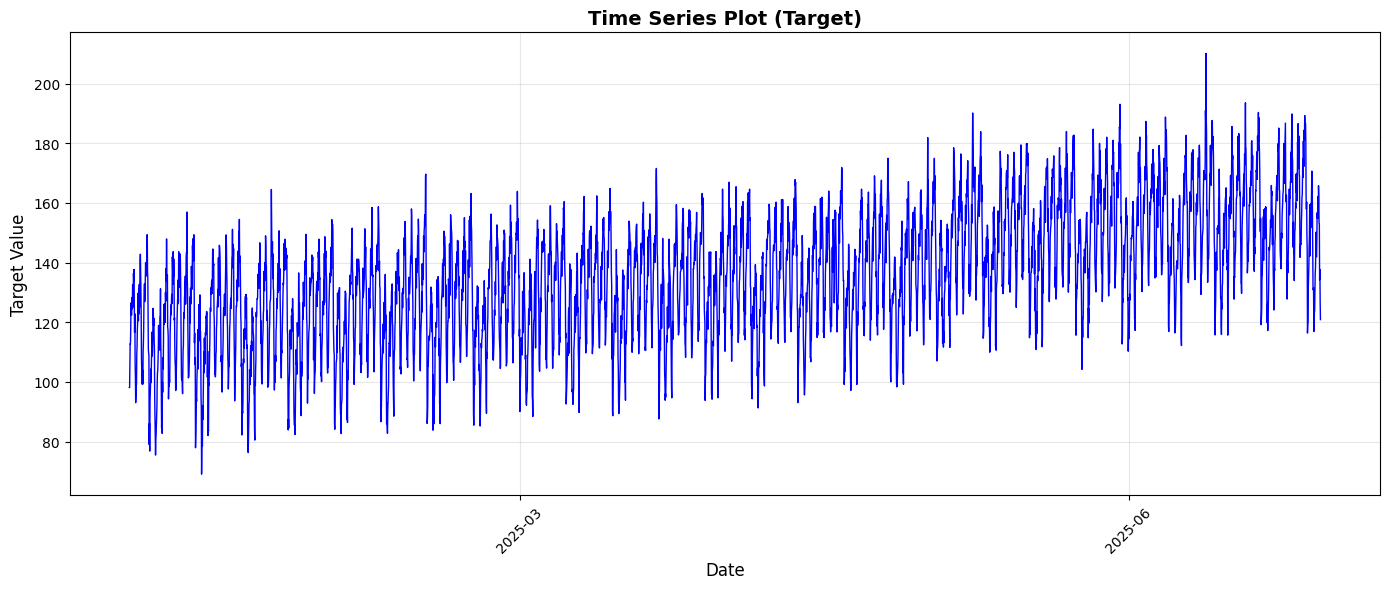

In [145]:

df = pd.read_csv('./data/S12-hw-dataset.csv')
print("ЗАГРУЗКА ДАННЫХ")
print(f"Размер датасета: {df.shape}")
print(f"\nКолонки: {df.columns.tolist()}")
print(f"\nПервые 5 строк:")
print(df.head())

# Преобразование даты и сортировка
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

print("\n ПРОВЕРКА ПРОПУСКОВ")
missing = df.isnull().sum()
print(missing)

# Обработка пропусков (если есть)
if missing.sum() > 0:
    print("\n Обнаружены пропуски! Заполняем методом forward fill.")
    df = df.ffill().bfill()
else:
    print("\n Пропусков не обнаружено.")

print("ДИАПАЗОН ДАТ")
print(f"Начало: {df['date'].min()}")
print(f"Конец: {df['date'].max()}")
print(f"Всего наблюдений: {len(df)}")
print(f"Период: {(df['date'].max() - df['date'].min()).days} дней")

# Базовый график временного ряда
print("ГРАФИК ВРЕМЕННОГО РЯДА")

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(df['date'], df['target'], linewidth=1, color='blue')
ax.set_title('Time Series Plot (Target)', fontsize=14, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Target Value', fontsize=12)
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('artifacts/figures/initial_series.png', dpi=300, bbox_inches='tight')
plt.show()

Краткий комментарий:
- Тренд: есть
- Сезонность: требуется дополнительный анализ
- Выбросы: требуют проверки
- Стационарность: вероятно нестационарный (требуется дифференцирование)

РАЗБИЕНИЕ ДАННЫХ (TEMPORAL SPLIT)
Train: 2592 наблюдений (2592)
  → 2025-01-01 00:00:00 до 2025-04-18 23:00:00
Validation: 864 наблюдений (864)
  → 2025-04-19 00:00:00 до 2025-05-24 23:00:00
Test: 864 наблюдений (864)
  → 2025-05-25 00:00:00 до 2025-06-29 23:00:00


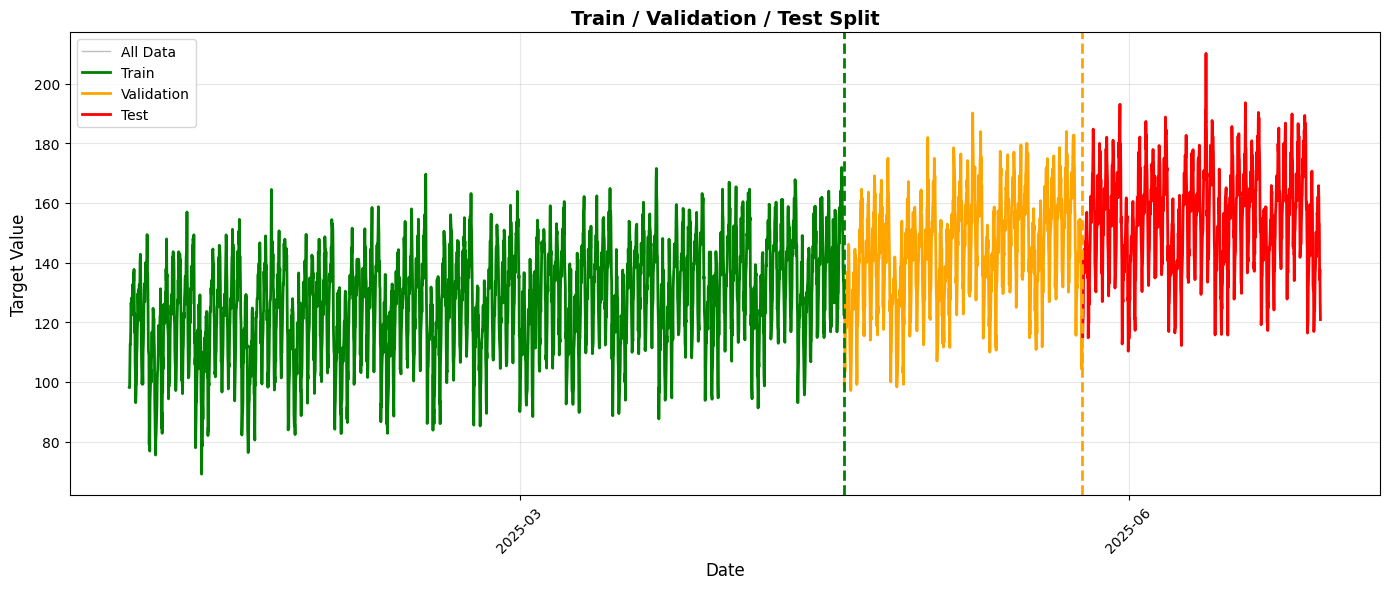

In [146]:

train_ratio = 0.6
val_ratio = 0.2
test_ratio = 0.2

n = len(df)
train_end = int(n * train_ratio)
val_end = int(n * (train_ratio + val_ratio))

# Разбиение
train_df = df.iloc[:train_end].copy()
val_df = df.iloc[train_end:val_end].copy()
test_df = df.iloc[val_end:].copy()

print("РАЗБИЕНИЕ ДАННЫХ (TEMPORAL SPLIT)")
print(f"Train: {len(train_df)} наблюдений ({train_end})")
print(f"  → {train_df['date'].min()} до {train_df['date'].max()}")
print(f"Validation: {len(val_df)} наблюдений ({val_end - train_end})")
print(f"  → {val_df['date'].min()} до {val_df['date'].max()}")
print(f"Test: {len(test_df)} наблюдений ({n - val_end})")
print(f"  → {test_df['date'].min()} до {test_df['date'].max()}")

# Визуализация разбиения
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(df['date'], df['target'], linewidth=1, color='gray', alpha=0.5, label='All Data')
ax.plot(train_df['date'], train_df['target'], linewidth=2, color='green', label='Train')
ax.plot(val_df['date'], val_df['target'], linewidth=2, color='orange', label='Validation')
ax.plot(test_df['date'], test_df['target'], linewidth=2, color='red', label='Test')

# Вертикальные линии границ
ax.axvline(x=train_df['date'].max(), color='green', linestyle='--', linewidth=2)
ax.axvline(x=val_df['date'].max(), color='orange', linestyle='--', linewidth=2)

ax.set_title('Train / Validation / Test Split', fontsize=14, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Target Value', fontsize=12)
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('artifacts/figures/series_split.png', dpi=300, bbox_inches='tight')
plt.show()

Объяснение почему в данном случае random_split некорректен

В задаче используется только temporal split так как временные ряды имеют зависимость и если мы будем использовать random_split, то это приведет к нереалистично завышенным метрикам.

In [147]:


def create_features(df, target_col='target'):
    """
    Создание признаков без утечки из будущего
    """
    df = df.copy()
    
    # Lag признаки (значения в прошлом)
    df['lag_1'] = df[target_col].shift(1)
    df['lag_7'] = df[target_col].shift(7)
    df['lag_14'] = df[target_col].shift(14)
    
    # Rolling признаки (скользящие статистики)
    df['rolling_mean_7'] = df[target_col].shift(1).rolling(window=7).mean()
    df['rolling_std_7'] = df[target_col].shift(1).rolling(window=7).std()
    
    # Календарные признаки
    df['day_of_week'] = df['date'].dt.dayofweek
    df['day_of_month'] = df['date'].dt.day
    df['month'] = df['date'].dt.month
    df['quarter'] = df['date'].dt.quarter
    df['day_of_year'] = df['date'].dt.dayofyear
    
    # One-hot encoding для дня недели
    for i in range(7):
        df[f'dow_{i}'] = (df['day_of_week'] == i).astype(int)
    
    return df

# Применяем ко всему датасету
df_features = create_features(df)

# Удаляем строки с NaN (из-за lag и rolling)
df_features = df_features.dropna().reset_index(drop=True)
print(f"Размер после создания признаков: {df_features.shape}")

# Разбиваем признаки по тем же границам
# Нужно найти индексы после dropna
train_start_idx = 0
# Находим где начинается train после dropna
train_dates = train_df['date'].min()
val_dates = val_df['date'].min()
test_dates = test_df['date'].min()

train_feat = df_features[df_features['date'] >= train_dates].copy()
train_feat = train_feat[train_feat['date'] < val_dates]

val_feat = df_features[df_features['date'] >= val_dates].copy()
val_feat = val_feat[val_feat['date'] < test_dates]

test_feat = df_features[df_features['date'] >= test_dates].copy()

print("ПРИЗНАКИ СОЗДАНЫ")
print(f"Train features: {train_feat.shape}")
print(f"Val features: {val_feat.shape}")
print(f"Test features: {test_feat.shape}")

# Список признаков для модели
feature_cols = ['lag_1', 'lag_7', 'lag_14', 'rolling_mean_7', 'rolling_std_7',
                'day_of_week', 'day_of_month', 'month', 'quarter',
                'dow_0', 'dow_1', 'dow_2', 'dow_3', 'dow_4', 'dow_5', 'dow_6']
print(f"\nИспользуемые признаки ({len(feature_cols)}): {feature_cols}")

Размер после создания признаков: (4306, 19)
ПРИЗНАКИ СОЗДАНЫ
Train features: (2578, 19)
Val features: (864, 19)
Test features: (864, 19)

Используемые признаки (16): ['lag_1', 'lag_7', 'lag_14', 'rolling_mean_7', 'rolling_std_7', 'day_of_week', 'day_of_month', 'month', 'quarter', 'dow_0', 'dow_1', 'dow_2', 'dow_3', 'dow_4', 'dow_5', 'dow_6']


In [148]:
# %%
# 2.3.5. Оконное представление для GRU

WINDOW_SIZE = 14  # Размер окна
HORIZON = 1  # Прогнозируем 1 шаг вперёд
BATCH_SIZE = 32

class TimeSeriesDataset(Dataset):
    """Dataset для временных рядов с окном"""
    def __init__(self, data, window_size, horizon=1):
        self.data = data
        self.window_size = window_size
        self.horizon = horizon
    
    def __len__(self):
        return len(self.data) - self.window_size - self.horizon + 1
    
    def __getitem__(self, idx):
        x = self.data[idx:idx + self.window_size]
        y = self.data[idx + self.window_size + self.horizon - 1]
        return torch.FloatTensor(x), torch.FloatTensor([y])

# Подготовка данных для GRU (только target)
train_values = train_df['target'].values.reshape(-1, 1)
val_values = val_df['target'].values.reshape(-1, 1)
test_values = test_df['target'].values.reshape(-1, 1)

# Масштабирование (fit только на train!)
scaler = StandardScaler()
train_scaled = scaler.fit_transform(train_values)
val_scaled = scaler.transform(val_values)
test_scaled = scaler.transform(test_values)

# Создание DataLoader
train_dataset = TimeSeriesDataset(train_scaled, WINDOW_SIZE, HORIZON)
val_dataset = TimeSeriesDataset(val_scaled, WINDOW_SIZE, HORIZON)
test_dataset = TimeSeriesDataset(test_scaled, WINDOW_SIZE, HORIZON)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("DATALOADER ДЛЯ GRU")
print(f"Window size: {WINDOW_SIZE}")
print(f"Horizon: {HORIZON}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

DATALOADER ДЛЯ GRU
Window size: 14
Horizon: 1
Batch size: 32
Train batches: 81
Val batches: 27
Test batches: 27


In [149]:
# %%
# 2.3.6. Модель GRU и функции обучения

class GRUModel(nn.Module):
    """GRU модель для прогнозирования временных рядов"""
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, dropout=0.2):
        super(GRUModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
        
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1)
        )
    
    def forward(self, x):
        # x shape: (batch, seq_len, input_size)
        gru_out, h_n = self.gru(x)
        # Берём последний выход
        out = self.fc(gru_out[:, -1, :])
        return out

# Инициализация модели
gru_model = GRUModel(input_size=1, hidden_size=64, num_layers=2, dropout=0.2).to(device)
print(gru_model)

# Функции метрик
def calculate_metrics(y_true, y_pred):
    """Расчёт MAE, RMSE, MAPE"""
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    # MAPE с защитой от деления на ноль
    mask = y_true != 0
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    return mae, rmse, mape

# Функция обучения
def train_model(model, train_loader, val_loader, epochs=50, lr=0.001, patience=10):
    """Обучение модели с early stopping"""
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    
    best_val_loss = float('inf')
    best_model_state = None
    patience_counter = 0
    
    history = {
        'train_loss': [],
        'val_loss': [],
        'val_mae': [],
        'val_rmse': [],
        'val_mape': []
    }
    
    print("\n" + "=" * 50)
    print("ОБУЧЕНИЕ МОДЕЛИ")
    print("=" * 50)
    
    for epoch in range(epochs):
        # Training
        model.train()
        train_loss = 0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            
            optimizer.zero_grad()
            output = model(X_batch)
            loss = criterion(output, y_batch)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
        
        train_loss /= len(train_loader)
        
        # Validation
        model.eval()
        val_loss = 0
        val_preds = []
        val_targets = []
        
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                output = model(X_batch)
                loss = criterion(output, y_batch)
                val_loss += loss.item()
                
                val_preds.append(output.cpu().numpy())
                val_targets.append(y_batch.cpu().numpy())
        
        val_loss /= len(val_loader)
        val_preds = np.vstack(val_preds).flatten()
        val_targets = np.vstack(val_targets).flatten()
        
        # Инверсное масштабирование для метрик
        val_preds_inv = scaler.inverse_transform(val_preds.reshape(-1, 1)).flatten()
        val_targets_inv = scaler.inverse_transform(val_targets.reshape(-1, 1)).flatten()
        
        val_mae, val_rmse, val_mape = calculate_metrics(val_targets_inv, val_preds_inv)
        
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_mae'].append(val_mae)
        history['val_rmse'].append(val_rmse)
        history['val_mape'].append(val_mape)
        
        # Early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = model.state_dict().copy()
            patience_counter = 0
        else:
            patience_counter += 1
        
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"Epoch {epoch+1}/{epochs} | "
                  f"Train Loss: {train_loss:.6f} | "
                  f"Val Loss: {val_loss:.6f} | "
                  f"Val MAE: {val_mae:.4f} | "
                  f"Val RMSE: {val_rmse:.4f}")
        
        if patience_counter >= patience:
            print(f"\n Early stopping at epoch {epoch+1}")
            break
    
    # Загружаем лучшую модель
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
    
    return model, history

GRUModel(
  (gru): GRU(1, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=32, out_features=1, bias=True)
  )
)


In [150]:
# %%
# 3. ЭКСПЕРИМЕНТЫ

results = []

# %%
# B1: Naive Last (наивный прогноз = последнее значение)
print("ЭКСПЕРИМЕНТ B1: NAIVE LAST")

# Прогноз = последнее известное значение из train
last_train_value = train_df['target'].iloc[-1]
val_preds_b1 = np.full(len(val_df), last_train_value)
test_preds_b1 = np.full(len(test_df), last_train_value)

val_mae_b1, val_rmse_b1, val_mape_b1 = calculate_metrics(val_df['target'].values, val_preds_b1)
test_mae_b1, test_rmse_b1, test_mape_b1 = calculate_metrics(test_df['target'].values, test_preds_b1)

print(f"Validation MAE: {val_mae_b1:.4f}")
print(f"Validation RMSE: {val_rmse_b1:.4f}")
print(f"Validation MAPE: {val_mape_b1:.4f}%")
print(f"Test MAE: {test_mae_b1:.4f}")

results.append({
    'experiment_id': 'B1',
    'task': 'forecasting',
    'dataset': 'S12-hw-dataset.csv',
    'seed': SEED,
    'split_summary': f'train={len(train_df)}, val={len(val_df)}, test={len(test_df)}',
    'window_size': None,
    'horizon': HORIZON,
    'model_summary': 'Naive Last - прогноз равен последнему значению train',
    'features_summary': 'None',
    'scaler': 'None',
    'optimizer': 'None',
    'lr': None,
    'epochs_trained': 0,
    'best_val_mae': val_mae_b1,
    'best_val_rmse': val_rmse_b1,
    'best_val_mape': val_mape_b1,
    'test_mae': test_mae_b1,
    'test_rmse': test_rmse_b1,
    'test_mape': test_mape_b1,
    'notes': 'Baseline без обучения'
})

ЭКСПЕРИМЕНТ B1: NAIVE LAST
Validation MAE: 24.0226
Validation RMSE: 28.3675
Validation MAPE: 15.7257%
Test MAE: 32.0115


In [151]:
# %%
# B2: Moving Average (скользящее среднее)
print("ЭКСПЕРИМЕНТ B2: MOVING AVERAGE")

WINDOW_MA = 7  # Окно для скользящего среднего

# Для validation: используем последние WINDOW_MA значений из train + val
val_preds_b2 = []
for i in range(len(val_df)):
    if i < WINDOW_MA:
        # Берём из конца train
        window = train_df['target'].iloc[-(WINDOW_MA-i):].tolist() + val_df['target'].iloc[:i].tolist()
    else:
        window = val_df['target'].iloc[i-WINDOW_MA:i].tolist()
    val_preds_b2.append(np.mean(window))
val_preds_b2 = np.array(val_preds_b2)

# Для test: используем последние из val
test_preds_b2 = []
full_series = pd.concat([train_df['target'], val_df['target'], test_df['target']], ignore_index=True)
train_val_len = len(train_df) + len(val_df)
for i in range(len(test_df)):
    start_idx = train_val_len + i - WINDOW_MA
    window = full_series.iloc[start_idx:start_idx + WINDOW_MA].values
    test_preds_b2.append(np.mean(window))
test_preds_b2 = np.array(test_preds_b2)

val_mae_b2, val_rmse_b2, val_mape_b2 = calculate_metrics(val_df['target'].values, val_preds_b2)
test_mae_b2, test_rmse_b2, test_mape_b2 = calculate_metrics(test_df['target'].values, test_preds_b2)

print(f"Validation MAE: {val_mae_b2:.4f}")
print(f"Validation RMSE: {val_rmse_b2:.4f}")
print(f"Validation MAPE: {val_mape_b2:.4f}%")
print(f"Test MAE: {test_mae_b2:.4f}")

results.append({
    'experiment_id': 'B2',
    'task': 'forecasting',
    'dataset': 'S12-hw-dataset.csv',
    'seed': SEED,
    'split_summary': f'train={len(train_df)}, val={len(val_df)}, test={len(test_df)}',
    'window_size': WINDOW_MA,
    'horizon': HORIZON,
    'model_summary': f'Moving Average с окном {WINDOW_MA}',
    'features_summary': 'rolling_mean',
    'scaler': 'None',
    'optimizer': 'None',
    'lr': None,
    'epochs_trained': 0,
    'best_val_mae': val_mae_b2,
    'best_val_rmse': val_rmse_b2,
    'best_val_mape': val_mape_b2,
    'test_mae': test_mae_b2,
    'test_rmse': test_rmse_b2,
    'test_mape': test_mape_b2,
    'notes': 'Baseline без обучения'
})

ЭКСПЕРИМЕНТ B2: MOVING AVERAGE
Validation MAE: 12.7321
Validation RMSE: 15.2206
Validation MAPE: 9.2686%
Test MAE: 12.7877


In [152]:
# %%
# B3: Ridge Regression на лаговых признаках
print("ЭКСПЕРИМЕНТ B3: RIDGE LAG FEATURES")

# Подготовка данных
X_train = train_feat[feature_cols].values
y_train = train_feat['target'].values
X_val = val_feat[feature_cols].values
y_val = val_feat['target'].values
X_test = test_feat[feature_cols].values
y_test = test_df['target'].values

# Масштабирование признаков (fit только на train)
feature_scaler = StandardScaler()
X_train_scaled = feature_scaler.fit_transform(X_train)
X_val_scaled = feature_scaler.transform(X_val)
X_test_scaled = feature_scaler.transform(X_test)

# Обучение Ridge
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train_scaled, y_train)

# Предсказания
val_preds_b3 = ridge_model.predict(X_val_scaled)
test_preds_b3 = ridge_model.predict(X_test_scaled)

val_mae_b3, val_rmse_b3, val_mape_b3 = calculate_metrics(y_val, val_preds_b3)
test_mae_b3, test_rmse_b3, test_mape_b3 = calculate_metrics(y_test, test_preds_b3)

print(f"Validation MAE: {val_mae_b3:.4f}")
print(f"Validation RMSE: {val_rmse_b3:.4f}")
print(f"Validation MAPE: {val_mape_b3:.4f}%")
print(f"Test MAE: {test_mae_b3:.4f}")

results.append({
    'experiment_id': 'B3',
    'task': 'forecasting',
    'dataset': 'S12-hw-dataset.csv',
    'seed': SEED,
    'split_summary': f'train={len(train_df)}, val={len(val_df)}, test={len(test_df)}',
    'window_size': None,
    'horizon': HORIZON,
    'model_summary': 'Ridge Regression (alpha=1.0)',
    'features_summary': f'{len(feature_cols)} признаков (lag, rolling, calendar)',
    'scaler': 'StandardScaler',
    'optimizer': 'None',
    'lr': None,
    'epochs_trained': 0,
    'best_val_mae': val_mae_b3,
    'best_val_rmse': val_rmse_b3,
    'best_val_mape': val_mape_b3,
    'test_mae': test_mae_b3,
    'test_rmse': test_rmse_b3,
    'test_mape': test_mape_b3,
    'notes': 'Linear model с лаговыми признаками'
})

ЭКСПЕРИМЕНТ B3: RIDGE LAG FEATURES
Validation MAE: 6.6869
Validation RMSE: 8.2569
Validation MAPE: 4.6202%
Test MAE: 7.4884


In [153]:
# %%
# R1: GRU Forecasting
print("ЭКСПЕРИМЕНТ R1: GRU FORECASTING")

# Переинициализация модели для чистоты эксперимента
gru_model = GRUModel(input_size=1, hidden_size=64, num_layers=2, dropout=0.2).to(device)

# Обучение
EPOCHS = 50
LEARNING_RATE = 0.001
PATIENCE = 10

trained_model, history = train_model(
    gru_model, 
    train_loader, 
    val_loader, 
    epochs=EPOCHS, 
    lr=LEARNING_RATE, 
    patience=PATIENCE
)

# Предсказания на validation
trained_model.eval()
val_preds_r1 = []
val_targets_r1 = []

with torch.no_grad():
    for X_batch, y_batch in val_loader:
        X_batch = X_batch.to(device)
        output = trained_model(X_batch)
        val_preds_r1.append(output.cpu().numpy())
        val_targets_r1.append(y_batch.cpu().numpy())

val_preds_r1 = np.vstack(val_preds_r1).flatten()
val_targets_r1 = np.vstack(val_targets_r1).flatten()

# Инверсное масштабирование
val_preds_r1_inv = scaler.inverse_transform(val_preds_r1.reshape(-1, 1)).flatten()
val_targets_r1_inv = scaler.inverse_transform(val_targets_r1.reshape(-1, 1)).flatten()

val_mae_r1, val_rmse_r1, val_mape_r1 = calculate_metrics(val_targets_r1_inv, val_preds_r1_inv)

# Предсказания на test
test_preds_r1 = []
test_targets_r1 = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        output = trained_model(X_batch)
        test_preds_r1.append(output.cpu().numpy())
        test_targets_r1.append(y_batch.cpu().numpy())

test_preds_r1 = np.vstack(test_preds_r1).flatten()
test_targets_r1 = np.vstack(test_targets_r1).flatten()

test_preds_r1_inv = scaler.inverse_transform(test_preds_r1.reshape(-1, 1)).flatten()
test_targets_r1_inv = scaler.inverse_transform(test_targets_r1.reshape(-1, 1)).flatten()

test_mae_r1, test_rmse_r1, test_mape_r1 = calculate_metrics(test_targets_r1_inv, test_preds_r1_inv)

print(f"\nValidation MAE: {val_mae_r1:.4f}")
print(f"Validation RMSE: {val_rmse_r1:.4f}")
print(f"Validation MAPE: {val_mape_r1:.4f}%")
print(f"Test MAE: {test_mae_r1:.4f}")

results.append({
    'experiment_id': 'R1',
    'task': 'forecasting',
    'dataset': 'S12-hw-dataset.csv',
    'seed': SEED,
    'split_summary': f'train={len(train_df)}, val={len(val_df)}, test={len(test_df)}',
    'window_size': WINDOW_SIZE,
    'horizon': HORIZON,
    'model_summary': f'GRU(hidden=64, layers=2, dropout=0.2)',
    'features_summary': 'raw target values in windows',
    'scaler': 'StandardScaler',
    'optimizer': 'Adam',
    'lr': LEARNING_RATE,
    'epochs_trained': len(history['train_loss']),
    'best_val_mae': val_mae_r1,
    'best_val_rmse': val_rmse_r1,
    'best_val_mape': val_mape_r1,
    'test_mae': test_mae_r1,
    'test_rmse': test_rmse_r1,
    'test_mape': test_mape_r1,
    'notes': 'Neural network approach'
})

ЭКСПЕРИМЕНТ R1: GRU FORECASTING

ОБУЧЕНИЕ МОДЕЛИ
Epoch 1/50 | Train Loss: 0.893393 | Val Loss: 1.027362 | Val MAE: 15.0440 | Val RMSE: 17.8968
Epoch 5/50 | Train Loss: 0.877401 | Val Loss: 1.001500 | Val MAE: 14.5919 | Val RMSE: 17.2912
Epoch 10/50 | Train Loss: 0.845425 | Val Loss: 0.912657 | Val MAE: 13.5692 | Val RMSE: 16.1248
Epoch 15/50 | Train Loss: 0.831334 | Val Loss: 0.894173 | Val MAE: 13.1768 | Val RMSE: 15.9144
Epoch 20/50 | Train Loss: 0.822181 | Val Loss: 0.858074 | Val MAE: 12.6578 | Val RMSE: 15.3754
Epoch 25/50 | Train Loss: 0.816703 | Val Loss: 0.853668 | Val MAE: 12.3053 | Val RMSE: 14.9456
Epoch 30/50 | Train Loss: 0.814023 | Val Loss: 0.848432 | Val MAE: 12.3306 | Val RMSE: 14.9790
Epoch 35/50 | Train Loss: 0.811608 | Val Loss: 0.853192 | Val MAE: 12.4100 | Val RMSE: 15.0759

 Early stopping at epoch 37

Validation MAE: 12.2853
Validation RMSE: 14.8716
Validation MAPE: 8.5562%
Test MAE: 13.6466


In [154]:
# %%
# 4. СОХРАНЕНИЕ АРТЕФАКТОВ

print("СОХРАНЕНИЕ АРТЕФАКТОВ")

# 1. runs.csv
results_df = pd.DataFrame(results)
results_df.to_csv('artifacts/runs.csv', index=False)
print(" Сохранено: artifacts/runs.csv")

# 2. best_gru.pt (сохраняем state_dict)
torch.save(trained_model.state_dict(), 'artifacts/best_gru.pt')
print(" Сохранено: artifacts/best_gru.pt")

# 3. best_gru_config.json
gru_config = {
    'input_size': 1,
    'hidden_size': 64,
    'num_layers': 2,
    'dropout': 0.2,
    'window_size': WINDOW_SIZE,
    'horizon': HORIZON,
    'batch_size': BATCH_SIZE,
    'learning_rate': LEARNING_RATE,
    'seed': SEED,
    'epochs_trained': len(history['train_loss']),
    'scaler_type': 'StandardScaler',
    'device': str(device)
}
with open('artifacts/best_gru_config.json', 'w') as f:
    json.dump(gru_config, f, indent=2)
print(" Сохранено: artifacts/best_gru_config.json")

СОХРАНЕНИЕ АРТЕФАКТОВ
 Сохранено: artifacts/runs.csv
 Сохранено: artifacts/best_gru.pt
 Сохранено: artifacts/best_gru_config.json


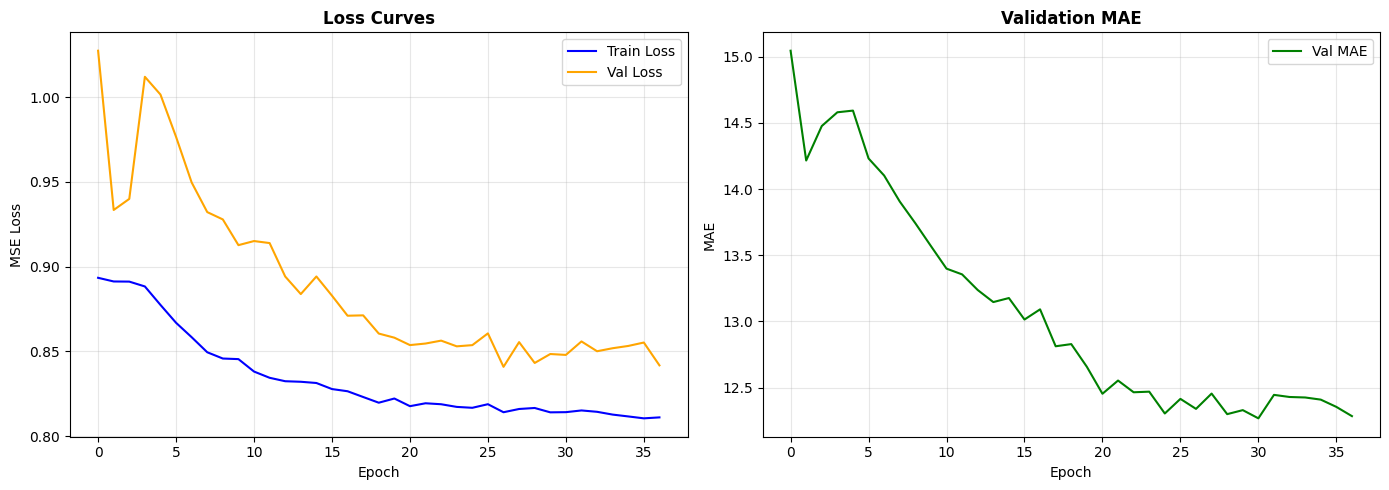

 Сохранено: artifacts/figures/gru_learning_curves.png


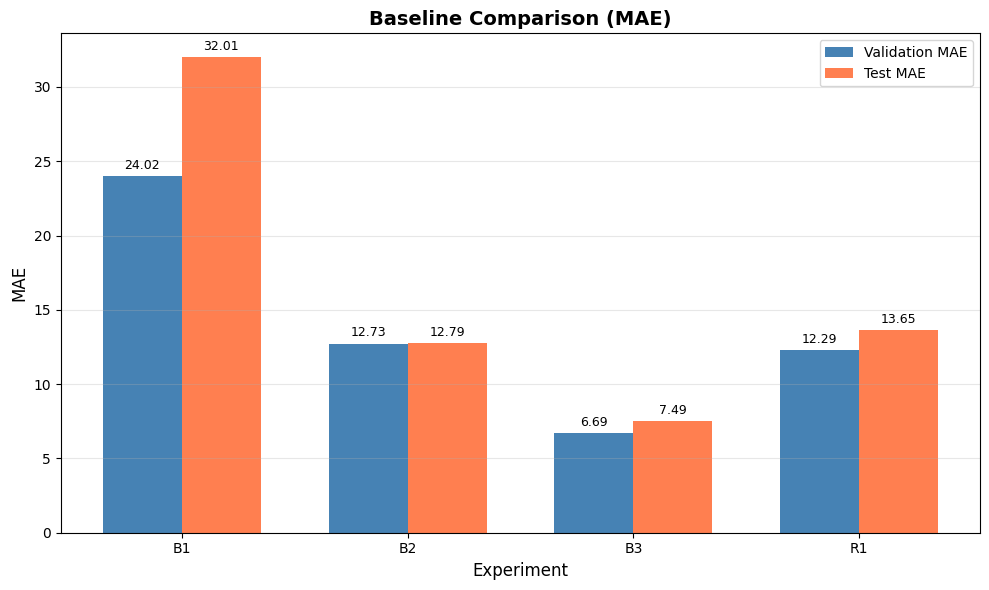

 Сохранено: artifacts/figures/baselines_compare.png

 Лучшая модель по Validation MAE: B3


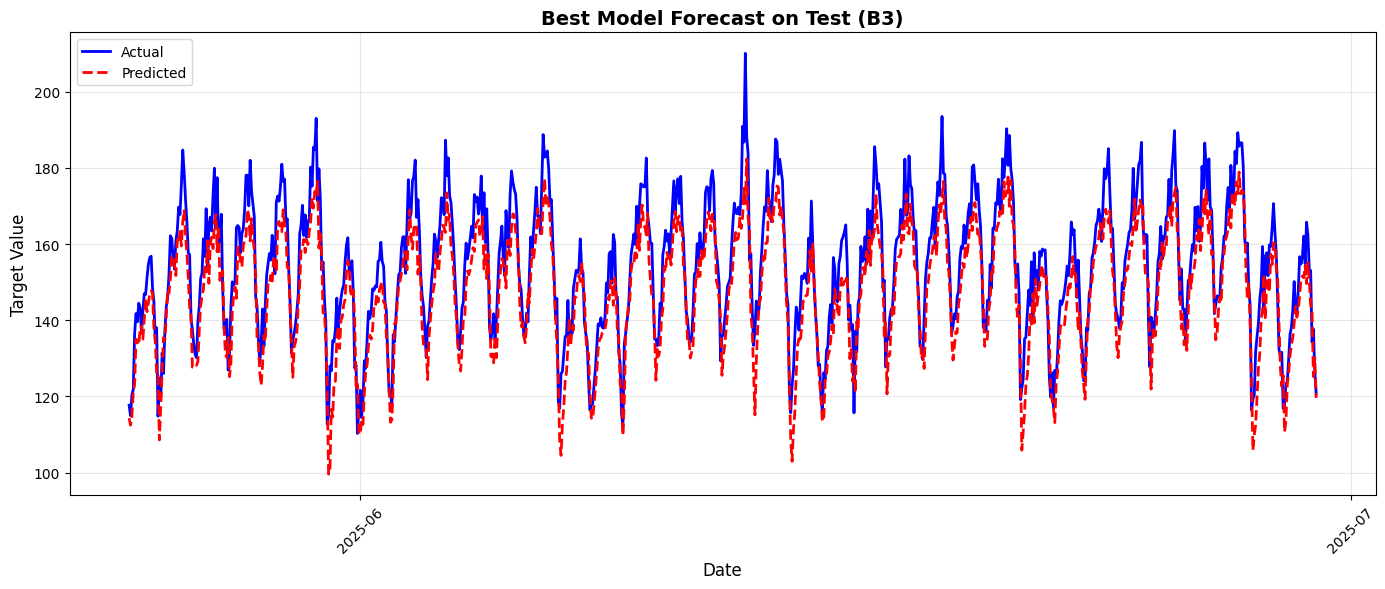

 Сохранено: artifacts/figures/best_forecast_test.png


In [155]:
# %%
# Графики для artifacts/figures/

# 1. Кривые обучения GRU
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history['train_loss'], label='Train Loss', color='blue')
axes[0].plot(history['val_loss'], label='Val Loss', color='orange')
axes[0].set_title('Loss Curves', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history['val_mae'], label='Val MAE', color='green')
axes[1].set_title('Validation MAE', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('artifacts/figures/gru_learning_curves.png', dpi=300, bbox_inches='tight')
plt.show()
print(" Сохранено: artifacts/figures/gru_learning_curves.png")

# 2. Сравнение baseline моделей
fig, ax = plt.subplots(figsize=(10, 6))

experiments = ['B1', 'B2', 'B3', 'R1']
val_maes = [val_mae_b1, val_mae_b2, val_mae_b3, val_mae_r1]
test_maes = [test_mae_b1, test_mae_b2, test_mae_b3, test_mae_r1]

x = np.arange(len(experiments))
width = 0.35

bars1 = ax.bar(x - width/2, val_maes, width, label='Validation MAE', color='steelblue')
bars2 = ax.bar(x + width/2, test_maes, width, label='Test MAE', color='coral')

ax.set_title('Baseline Comparison (MAE)', fontsize=14, fontweight='bold')
ax.set_xlabel('Experiment', fontsize=12)
ax.set_ylabel('MAE', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(experiments)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# Добавляем значения на столбцы
for bar in bars1:
    height = bar.get_height()
    ax.annotate(f'{height:.2f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points",
                ha='center', va='bottom', fontsize=9)

for bar in bars2:
    height = bar.get_height()
    ax.annotate(f'{height:.2f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points",
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('artifacts/figures/baselines_compare.png', dpi=300, bbox_inches='tight')
plt.show()
print(" Сохранено: artifacts/figures/baselines_compare.png")

# 3. Лучший прогноз на test
# Определяем лучшую модель по validation MAE
best_exp = results_df.loc[results_df['best_val_mae'].idxmin()]
print(f"\n Лучшая модель по Validation MAE: {best_exp['experiment_id']}")

# Выбираем прогнозы лучшей модели
if best_exp['experiment_id'] == 'B1':
    best_test_preds = test_preds_b1
elif best_exp['experiment_id'] == 'B2':
    best_test_preds = test_preds_b2
elif best_exp['experiment_id'] == 'B3':
    best_test_preds = test_preds_b3
else:
    best_test_preds = test_preds_r1_inv

# График факта и прогноза
fig, ax = plt.subplots(figsize=(14, 6))

# Показываем конец val + весь test
plot_start = len(val_df) - 30  # Последние 30 дней val
plot_end = len(test_df)

dates_plot = test_df['date'].values
actual_plot = test_df['target'].values

ax.plot(test_df['date'], actual_plot, linewidth=2, color='blue', label='Actual')
ax.plot(test_df['date'], best_test_preds, linewidth=2, color='red', linestyle='--', label='Predicted')

ax.set_title(f'Best Model Forecast on Test ({best_exp["experiment_id"]})', fontsize=14, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Target Value', fontsize=12)
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator())
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('artifacts/figures/best_forecast_test.png', dpi=300, bbox_inches='tight')
plt.show()
print(" Сохранено: artifacts/figures/best_forecast_test.png")

In [156]:
# %%
# Сводная таблица
print("\n" + "=" * 50)
print("СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ")
print("=" * 50)

summary_df = results_df[['experiment_id', 'best_val_mae', 'best_val_rmse', 'best_val_mape', 
                          'test_mae', 'test_rmse', 'test_mape', 'model_summary']]
print(summary_df.to_string(index=False))

# Лучшая модель
best_model = results_df.loc[results_df['best_val_mae'].idxmin()]
print(f"\n ЛУЧШАЯ МОДЕЛЬ ПО VALIDATION: {best_model['experiment_id']}")
print(f"   Validation MAE: {best_model['best_val_mae']:.4f}")
print(f"   Test MAE: {best_model['test_mae']:.4f}")


СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ
experiment_id  best_val_mae  best_val_rmse  best_val_mape  test_mae  test_rmse  test_mape                                        model_summary
           B1     24.022639      28.367452      15.725653 32.011516  36.006079  19.794289 Naive Last - прогноз равен последнему значению train
           B2     12.732085      15.220604       9.268566 12.787687  15.286118   8.635108                             Moving Average с окном 7
           B3      6.686945       8.256909       4.620223  7.488434   9.131583   4.814779                         Ridge Regression (alpha=1.0)
           R1     12.285326      14.871562       8.556183 13.646563  16.516058   8.635410                GRU(hidden=64, layers=2, dropout=0.2)

 ЛУЧШАЯ МОДЕЛЬ ПО VALIDATION: B3
   Validation MAE: 6.6869
   Test MAE: 7.4884
